# Primena neuronskih mreža za predviđanje prevara u cyber bezbednosti (spam)

MLP klasifikator (PyTorch + skorch) nad TF-IDF vektorima SMS poruka, sa GridSearchCV hiperparametarskom optimizacijom i analizom osetljivosti.

In [2]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import Counter

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve,
)
from skorch import NeuralNetBinaryClassifier

from data_utils import load_raw, clean_text, split_dataset, vectorize
from model import SpamMLP

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

## 1. Preprocesiranje podataka

Dataset: [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) - 5572 SMS poruke označene kao `ham` (legitimna) ili `spam`.

In [3]:
df = load_raw("../data/raw/spam.csv")
print(df.shape)
df.head()

(5572, 2)


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


label
0    4825
1     747
Name: count, dtype: int64
Udeo spam poruka: 13.4%


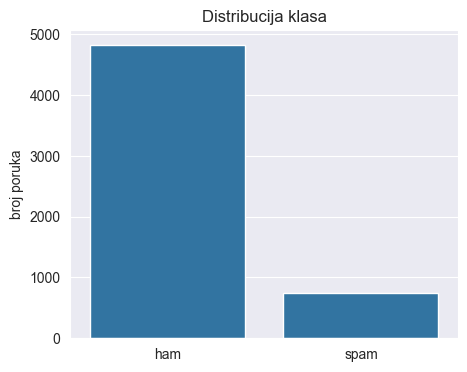

In [4]:
# Distribucija klasa (ham=0, spam=1) - dataset je umereno neuravnotežen
class_counts = df["label"].value_counts()
print(class_counts)
print(f"Udeo spam poruka: {class_counts[1] / len(df):.1%}")

plt.figure(figsize=(5, 4))
sns.barplot(x=["ham", "spam"], y=class_counts.sort_index().values)
plt.ylabel("broj poruka")
plt.title("Distribucija klasa")
plt.savefig("../results/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

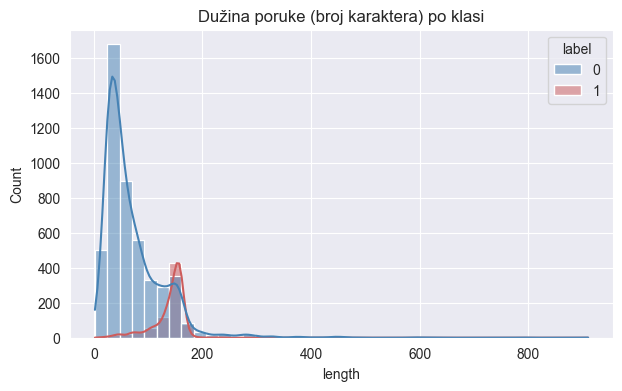

In [5]:
# Dužina poruka po klasi
df["length"] = df["text"].str.len()

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="length", hue="label", bins=40, kde=True, palette={0: "steelblue", 1: "indianred"})
plt.title("Dužina poruke (broj karaktera) po klasi")
plt.savefig("../results/figures/message_length.png", dpi=150, bbox_inches="tight")
plt.show()

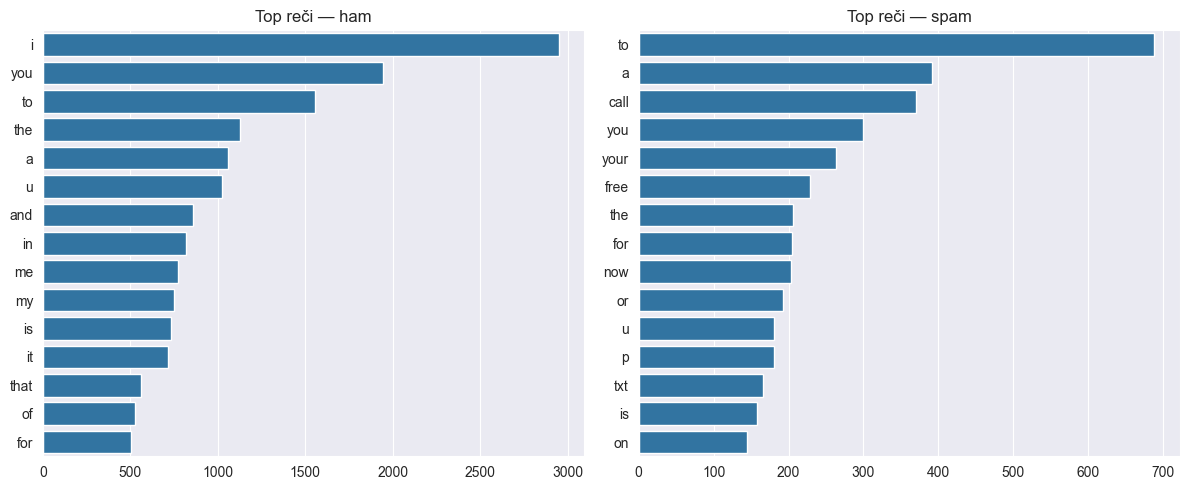

In [6]:
# Najčešće reči po klasi (nakon čišćenja teksta)
def top_words(texts, n=15):
    words = " ".join(texts).split()
    return Counter(words).most_common(n)

cleaned_preview = df["text"].apply(clean_text)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, label, name in zip(axes, [0, 1], ["ham", "spam"]):
    words, counts = zip(*top_words(cleaned_preview[df["label"] == label]))
    sns.barplot(x=list(counts), y=list(words), ax=ax)
    ax.set_title(f"Top reči - {name}")
plt.tight_layout()
plt.savefig("../results/figures/top_words.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
# Preprocesiranje: čišćenje teksta -> stratifikovan train/val/test split (PRE vektorizacije) -> TF-IDF fit samo na train
df["text"] = df["text"].apply(clean_text)

train_df, val_df, test_df = split_dataset(df, val_size=0.15, test_size=0.15, random_state=SEED)
print(f"train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")

vectorizer, (X_train, y_train), (X_val, y_val), (X_test, y_test) = vectorize(
    train_df, val_df, test_df, max_features=3000, ngram_range=(1, 2)
)
X_train.shape, X_val.shape, X_test.shape

train: 3900, val: 836, test: 836


((3900, 3000), (836, 3000), (836, 3000))

## 2. Arhitektura modela

`SpamMLP` (definisan u `src/model.py`): konfigurabilan feedforward klasifikator nad TF-IDF vektorima.

- Ulaz: TF-IDF vektor (dimenzija = `max_features`)
- N skrivenih slojeva (`n_hidden_layers`), svaki: Linear -> aktivacija (ReLU/Tanh) -> Dropout
- Izlaz: 1 logit (binarna klasifikacija spam/ham), sigmoid se primenjuje implicitno kroz `BCEWithLogitsLoss` / `predict_proba`

In [8]:
example_model = SpamMLP(input_dim=X_train.shape[1], n_hidden_layers=2, hidden_dim=128, dropout=0.3, activation="relu")
print(example_model)
print(f"Broj parametara: {sum(p.numel() for p in example_model.parameters()):,}")

SpamMLP(
  (net): Sequential(
    (0): Linear(in_features=3000, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)
Broj parametara: 400,769


## 3. Trening (baseline)

Prvo treniramo model sa razumnim default hiperparametrima da potvrdimo da ceo pipeline radi end-to-end, pre nego što krenemo u hiperparametarsku optimizaciju.

In [9]:
# Class imbalance: ponder pozitivnu (spam) klasu u loss funkciji umesto oversampling-a
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
pos_weight = torch.tensor(n_neg / n_pos, dtype=torch.float32)

baseline_net = NeuralNetBinaryClassifier(
    module=SpamMLP,
    module__input_dim=X_train.shape[1],
    module__n_hidden_layers=2,
    module__hidden_dim=128,
    module__dropout=0.3,
    module__activation="relu",
    criterion=torch.nn.BCEWithLogitsLoss,
    criterion__pos_weight=pos_weight,
    optimizer=torch.optim.Adam,
    lr=1e-3,
    batch_size=64,
    max_epochs=30,
    train_split=None,
    device=DEVICE,
    verbose=0,
)

baseline_net.fit(X_train, y_train)
None

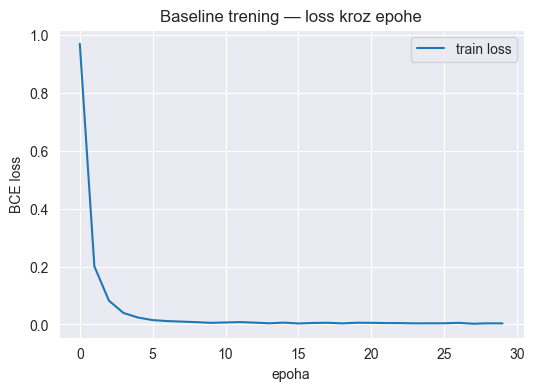

Baseline val F1: 0.893


In [10]:
history = baseline_net.history
train_loss = history[:, "train_loss"]

plt.figure(figsize=(6, 4))
plt.plot(train_loss, label="train loss")
plt.xlabel("epoha")
plt.ylabel("BCE loss")
plt.title("Baseline trening - loss kroz epohe")
plt.legend()
plt.savefig("../results/figures/baseline_loss.png", dpi=150, bbox_inches="tight")
plt.show()

val_probs = baseline_net.predict_proba(X_val)[:, 1]
val_preds = (val_probs >= 0.5).astype(int)
print(f"Baseline val F1: {f1_score(y_val, val_preds):.3f}")

Zaključak: Trening loss opada glatko i monotono kroz svih 30 epoha, bez oscilacija ili naglih skokova - model uči stabilno i izabrana konfiguracija (Adam, lr=1e-3) ne dovodi do divergencije. Prikazan je samo trening loss (nema posebne validacione krive na ovom grafiku, jer se tokom baseline treninga ne koristi interni validacioni split) - sama kriva zato ne može da pokaže overfitting; za to služi F1 izmeren posebno na validacionom skupu nakon treninga (0.893), čime je potvrđeno da ceo pipeline (podaci → model → trening) radi ispravno pre prelaska na hiperparametarsku optimizaciju.

## 4. Hiperparametarska optimizacija i analiza osetljivosti

`GridSearchCV` preko skorch wrappera (cross-validated grid search direktno nad PyTorch mrežom). Pretraga se radi nad train+val skupom (CV sam pravi fold-ove); test skup ostaje potpuno odvojen do finalne evaluacije.

In [11]:
X_cv = np.concatenate([X_train, X_val], axis=0)
y_cv = np.concatenate([y_train, y_val], axis=0)

n_pos_cv = y_cv.sum()
n_neg_cv = len(y_cv) - n_pos_cv
pos_weight_cv = torch.tensor(n_neg_cv / n_pos_cv, dtype=torch.float32)

grid_net = NeuralNetBinaryClassifier(
    module=SpamMLP,
    module__input_dim=X_cv.shape[1],
    criterion=torch.nn.BCEWithLogitsLoss,
    criterion__pos_weight=pos_weight_cv,
    optimizer=torch.optim.Adam,
    batch_size=64,
    max_epochs=15,
    train_split=None,
    device=DEVICE,
    verbose=0,
)

# Grid namerno umeren (108 kombinacija x 5-fold = 540 treninga) da pretraga
# ostane izvodljiva na CPU u razumnom vremenu, uz zadrzavanje bar 2-3
# vrednosti po hiperparametru za smislenu analizu osetljivosti.
param_grid = {
    "module__n_hidden_layers": [1, 2],
    "module__hidden_dim": [64, 128],
    "module__dropout": [0.0, 0.3],
    "module__activation": ["relu", "tanh"],
    "lr": [1e-3],
}

search = GridSearchCV(grid_net, param_grid, scoring="f1", cv=5, n_jobs=1, refit=True, verbose=1)
search.fit(X_cv, y_cv)

print("Best params:", search.best_params_)
print(f"Best CV F1: {search.best_score_:.3f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
  epoch    train_loss     dur
-------  ------------  ------
      1        1.0994  0.1507
      2        0.6614  0.1467
      3        0.3276  0.1820
      4        0.1952  0.2040
      5        0.1346  0.1692
      6        0.0999  0.2357
      7        0.0776  0.2199
      8        0.0622  0.1593
      9        0.0511  0.1918
     10        0.0429  0.1593
     11        0.0366  0.1731
     12        0.0317  0.1928
     13        0.0278  0.1800
     14        0.0247  0.1746
     15        0.0221  0.2348
  epoch    train_loss     dur
-------  ------------  ------
      1        1.0936  0.7943
      2        0.6443  0.2677
      3        0.3151  0.2493
      4        0.1863  0.2411
      5        0.1280  0.1994
      6        0.0952  0.2233
      7        0.0742  0.1775
      8        0.0599  0.1635
      9        0.0496  0.1238
     10        0.0420  0.1294
     11        0.0363  0.1249
     12        0.0319  0.1300
     13  

In [12]:
results_df = pd.DataFrame(search.cv_results_)
results_df = results_df.sort_values("mean_test_score", ascending=False)
results_df[[c for c in results_df.columns if c.startswith("param_")] + ["mean_test_score", "std_test_score"]].head(15)

,param_lr,param_module__activation,param_module__dropout,param_module__hidden_dim,param_module__n_hidden_layers,mean_test_score,std_test_score
8,0.001,tanh,0.0,64,1,0.931472,0.020919
14,0.001,tanh,0.3,128,1,0.931350,0.021078
0,0.001,relu,0.0,64,1,0.930298,0.020824
2,0.001,relu,0.0,128,1,0.930205,0.021411
10,0.001,tanh,0.0,128,1,0.929773,0.022183
12,0.001,tanh,0.3,64,1,0.929370,0.023308
6,0.001,relu,0.3,128,1,0.928922,0.022962
4,0.001,relu,0.3,64,1,0.928777,0.023438
13,0.001,tanh,0.3,64,2,0.917075,0.018862
5,0.001,relu,0.3,64,2,0.916627,0.021690


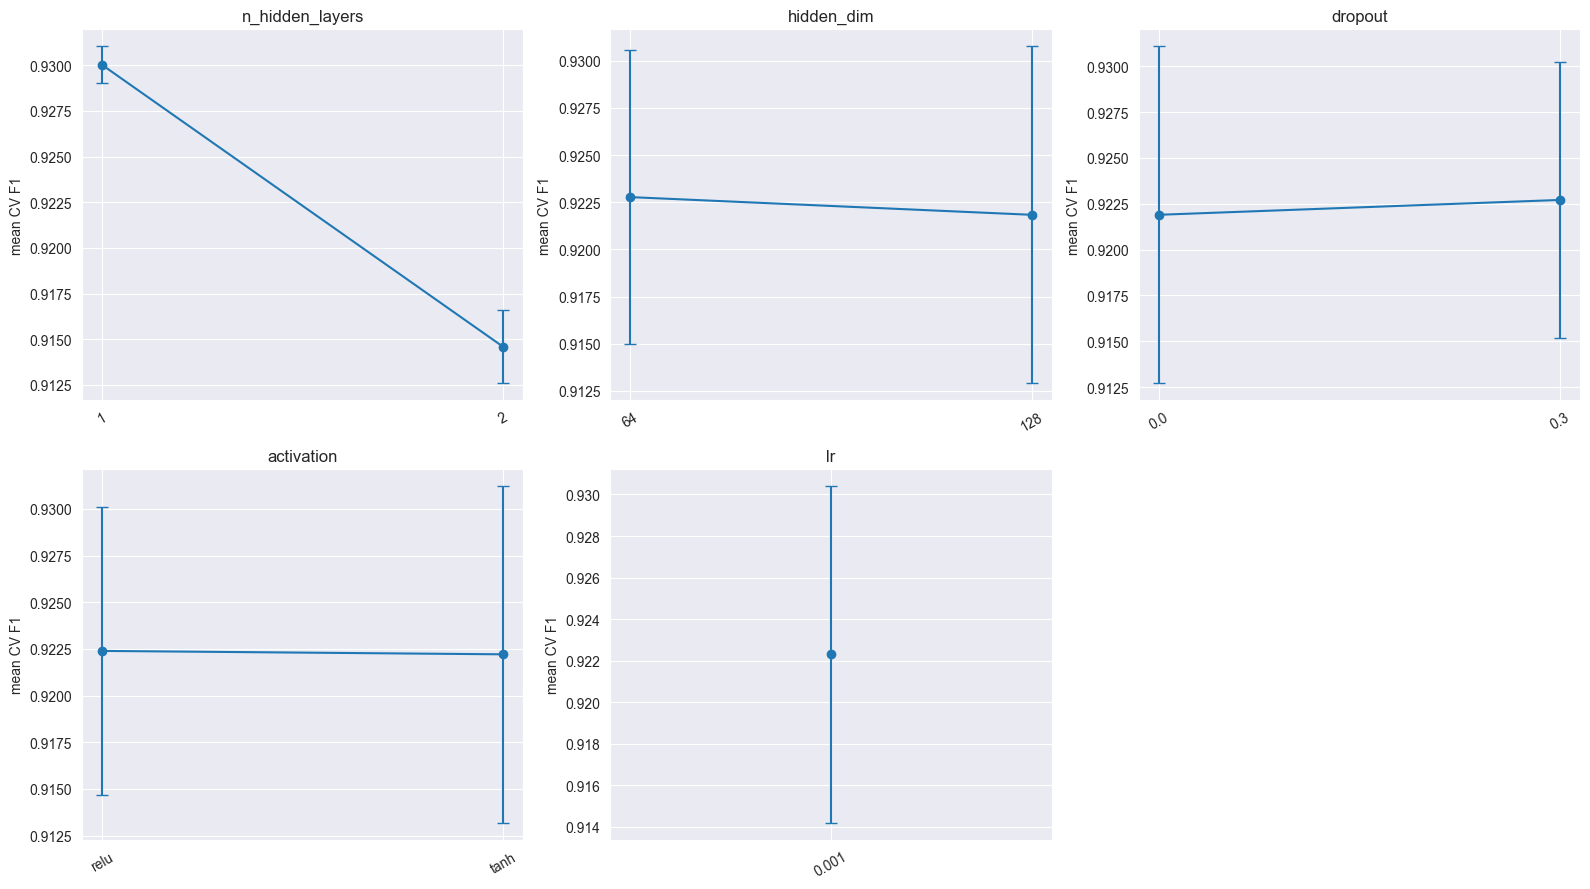

In [13]:
# Analiza osetljivosti: za svaki hiperparametar posebno, prosečan CV F1 po vrednosti
# (marginalizovano preko svih ostalih kombinacija u grid-u - pokazuje opšti trend uticaja)
hp_params = ["module__n_hidden_layers", "module__hidden_dim", "module__dropout",
             "module__activation", "lr"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, param in zip(axes.flat, hp_params):
    col = f"param_{param}"
    grouped = results_df.groupby(col)["mean_test_score"].agg(["mean", "std"]).reset_index()
    ax.errorbar(grouped[col].astype(str), grouped["mean"], yerr=grouped["std"], marker="o", capsize=4)
    ax.set_title(param.replace("module__", ""))
    ax.set_ylabel("mean CV F1")
    ax.tick_params(axis="x", rotation=30)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.savefig("../results/figures/hyperparameter_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

**Zaključak:** Grafici pokazuju prosečan CV F1 za svaku vrednost hiperparametra, usrednjeno preko svih ostalih kombinacija u grid-u (lr je fiksiran na jednu vrednost, pa nema svoj grafik).

- **Broj skrivenih slojeva** ima ubedljivo najveći uticaj: 1 sloj daje prosečan F1 ≈ 0.930, dok 2 sloja padaju na ≈ 0.915 — razlika od skoro 1.5 procentna poena, najveća razlika u celom grid-u. Sa svega ~4700 trening uzoraka, dublja mreža (2 sloja, više parametara) teže generalizuje.
- **Broj neurona po sloju** (64 vs 128), **dropout** (0.0 vs 0.3) i **aktivaciona funkcija** (ReLU vs Tanh) imaju zanemarljiv uticaj — razlike u proseku manje od 0.002 F1 poena, praktično u granicama šuma (std_test_score je reda veličine 0.02, mnogo veći od ovih razlika).

**Praktičan zaključak:** za ovaj problem i dataset, dubina mreže je jedini hiperparametar koji zaista menja rezultat u ispitanom opsegu; ostala tri se mogu birati slobodno bez značajnog gubitka performansi.

## 5. Finalna evaluacija

Najbolji model (`search.best_estimator_`, treniran na train+val sa najboljim hiperparametrima) evaluiran na test skupu koji nije korišćen ni u jednom koraku optimizacije.

In [14]:
best_model = search.best_estimator_

test_probs = best_model.predict_proba(X_test)[:, 1]
test_preds = (test_probs >= 0.5).astype(int)

metrics = {
    "accuracy": accuracy_score(y_test, test_preds),
    "precision": precision_score(y_test, test_preds),
    "recall": recall_score(y_test, test_preds),
    "f1": f1_score(y_test, test_preds),
    "roc_auc": roc_auc_score(y_test, test_probs),
}
for k, v in metrics.items():
    print(f"{k:>10}: {v:.3f}")

  accuracy: 0.986
 precision: 0.955
    recall: 0.938
        f1: 0.946
   roc_auc: 0.986


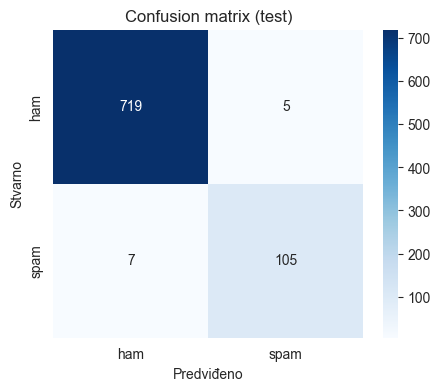

In [15]:
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.xlabel("Predviđeno")
plt.ylabel("Stvarno")
plt.title("Confusion matrix (test)")
plt.savefig("../results/figures/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

**Zaključak:** Od 836 poruka u test skupu (724 ham, 112 spam):

- **719** ham poruka je tačno prepoznato kao ham
- **5** ham poruka je pogrešno označeno kao spam (lažno pozitivno - legitimna poruka bi bila blokirana)
- **7** spam poruka je pogrešno propušteno kao ham (lažno negativno - spam koji bi promakao)
- **105** spam poruka je tačno prepoznato

Model greši retko i u oba smera malo (5 naspram 7 grešaka od ukupno 836 poruka), što je odličan rezultat s obzirom da je spam samo 13% podataka - model dakle nije "prevario" metriku tako što jednostavno sve predviđa kao ham (u tom slučaju bi imao 0 grešaka na ham klasi, ali bi promašio svih 112 spam poruka).

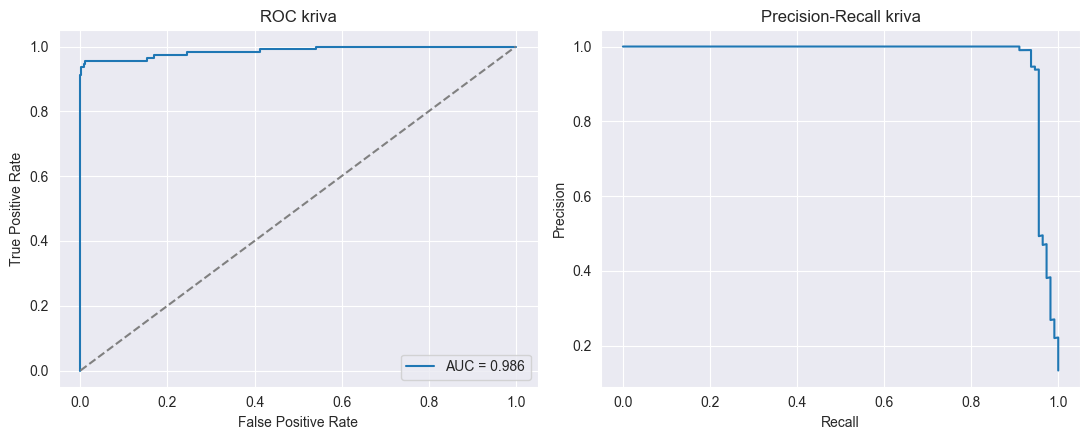

In [16]:
fpr, tpr, _ = roc_curve(y_test, test_probs)
prec, rec, _ = precision_recall_curve(y_test, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC kriva")
axes[0].legend()

axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall kriva")

plt.tight_layout()
plt.savefig("../results/figures/roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Zaključak:** ROC kriva se gotovo lepi za gornji levi ugao (AUC = 0.986), što znači da model gotovo savršeno razdvaja spam od ham poruka nezavisno od izabranog praga za odlučivanje (ne samo na pragu 0.5 korišćenom ranije). Precision-Recall kriva ostaje visoka (precision blizu 1.0) sve dok recall ne pređe ~0.9, i tek tada počinje primetno da opada - model, dakle, može da uhvati veliku većinu spama pre nego što počne ozbiljnije da žrtvuje preciznost (odnosno da pogrešno optužuje legitimne poruke).

Zajedno, obe krive potvrđuju da rezultat iz confusion matrice (5 lažno pozitivnih, 7 lažno negativnih na pragu 0.5) nije slučajnost vezana za baš taj prag - model realno dobro razdvaja klase u širokom opsegu mogućih pragova.

In [17]:
torch.save(best_model.module_.state_dict(), "../results/best_model.pt")
print("Sačuvano: ../results/best_model.pt")

Sačuvano: ../results/best_model.pt
